# Prophet for Financial Forecasting: Separating Marketing from Reality

**Chapter 12, Notebook 3:** `B37124_12_03_prophet_debunking.ipynb`

## Financial Trading with Python, 2nd Edition

---

Meta's Prophet library appears in countless online articles claiming to predict stock prices. It is easy to use, produces professional-looking charts with confidence intervals, and requires almost no statistical knowledge. That combination has made it one of the most popular tools for financial forecasting tutorials, and one of the most misapplied.

Prophet was built for business metrics: retail sales, web traffic, resource consumption. These are series with strong daily, weekly, and yearly seasonality, a clear long-term trend, and low noise relative to the seasonal pattern. Financial returns have none of these properties. Daily equity returns have no meaningful seasonality, no stable trend, and a signal-to-noise ratio near zero. Fitting Prophet to SPY and calling it a forecast is like using a metal detector on the ocean: the tool works, but the environment is wrong.

This notebook has three parts:

- **Section 1** reproduces the typical online tutorial approach: fit Prophet to SPY daily closing prices, generate a forecast, and show the chart that makes the articles look convincing
- **Section 2** applies the walk-forward rigor from Notebooks 1 and 2 and evaluates Prophet as a trading signal rather than a chart
- **Section 3** applies Prophet to PPI corrugated boxes from FRED, a series with genuine seasonality, to demonstrate that the model works when its assumptions are met

**What we will cover:**

- Why fitting Prophet to prices instead of returns is misleading
- The confidence interval illusion in Prophet's default output
- Walk-forward evaluation of Prophet as a daily trading signal
- The contrast between financial data and economic data with real seasonal structure
- How to match the right tool to the right data

### FRED API Key Setup

This notebook downloads economic data from FRED (Federal Reserve Economic Data). FRED requires a free API key for programmatic access. If you do not already have one:

1. Go to https://fred.stlouisfed.org/docs/api/api_key.html
2. Create a free account (or log in if you already have one)
3. Request an API key from your account settings
4. In Google Colab, click the key icon in the left sidebar to open **Secrets**
5. Add a new secret with the name `FRED_API_KEY` and paste your key as the value
6. Toggle the **Notebook access** switch to enable it for this notebook

The cell below will retrieve the key automatically. This approach keeps your API key out of the notebook code, which is important if you share your notebooks or push them to GitHub.

## Section 1: The "Medium Article" Approach

### Setup and data loading

We need SPY daily prices from yfinance and PPI corrugated boxes from FRED. Prophet requires a specific DataFrame format: a column named `ds` for dates and a column named `y` for the values to forecast.

In [4]:
# ============================================================
# Setup and Configuration
# ============================================================
# Prophet can be slow to install in Colab due to its
# dependency on pystan. The install may take 1-2 minutes.
#
# fredapi is the official Python wrapper for the FRED API.
# It requires a free API key (see the markdown cell above).
# ============================================================

!pip install prophet fredapi yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
from prophet import Prophet
import warnings
import time
import os
from google.colab import userdata

warnings.filterwarnings('ignore')

# ── FRED API Key ────────────────────────────────────────────
# Retrieved from Colab Secrets. See the markdown cell above
# for instructions on setting this up.
# ────────────────────────────────────────────────────────────
FRED_API_KEY = userdata.get('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

# ── Parameters ──────────────────────────────────────────────
TICKER = 'SPY'
START_DATE = '2005-01-01'
END_DATE = '2025-12-31'

# Single train/test split for Section 1 (the "bad" approach)
TRAIN_END = '2022-12-31'

# Walk-forward parameters for Section 2
TRAIN_WINDOW = 504          # ~2 years of trading days
REFIT_FREQUENCY = 5         # Refit every 5 trading days (weekly)

# FRED series for Section 3
FRED_PPI = 'PCU322211322211'  # PPI: Corrugated and solid fiber boxes

# Evaluation parameters
RISK_FREE_RATE = 0.0
TRADING_DAYS_PER_YEAR = 252

# Data caching
CACHE_SPY = 'ch12_nb03_spy.parquet'
CACHE_PPI = 'ch12_nb03_ppi.parquet'

# Print library versions
import prophet as prophet_module
print(f"numpy:    {np.__version__}")
print(f"pandas:   {pd.__version__}")
print(f"prophet:  {prophet_module.__version__}")
print(f"yfinance: {yf.__version__}")

numpy:    2.0.2
pandas:   2.2.2
prophet:  1.3.0
yfinance: 0.2.66


In [5]:
# ============================================================
# Download and Cache Data
# ============================================================
# SPY daily prices from yfinance for Sections 1 and 2.
# PPI corrugated boxes from FRED for Section 3.
#
# We cache both to parquet files.
# ============================================================

# --- SPY ---
if os.path.exists(CACHE_SPY):
    print(f"Loading cached SPY data from {CACHE_SPY}")
    df_spy = pd.read_parquet(CACHE_SPY)
else:
    print("Downloading SPY from yfinance...")
    df_spy = yf.download(TICKER, start=START_DATE, end=END_DATE)[['Close']]
    df_spy.columns = ['close']
    df_spy.to_parquet(CACHE_SPY)
    print(f"Saved to {CACHE_SPY}")

# --- PPI Corrugated Boxes ---
if os.path.exists(CACHE_PPI):
    print(f"Loading cached PPI data from {CACHE_PPI}")
    df_ppi = pd.read_parquet(CACHE_PPI)
else:
    print("Downloading PPI corrugated boxes from FRED...")
    ppi_series = fred.get_series(FRED_PPI,
                                 observation_start='1985-01-01',
                                 observation_end=END_DATE)
    df_ppi = ppi_series.to_frame(name='ppi').dropna()
    df_ppi.to_parquet(CACHE_PPI)
    print(f"Saved to {CACHE_PPI}")

# --- Summary ---
print(f"\nSPY:")
print(f"  Date range: {df_spy.index[0].strftime('%Y-%m-%d')} to "
      f"{df_spy.index[-1].strftime('%Y-%m-%d')}")
print(f"  Trading days: {len(df_spy):,}")

print(f"\nPPI Corrugated Boxes:")
print(f"  Date range: {df_ppi.index[0].strftime('%Y-%m-%d')} to "
      f"{df_ppi.index[-1].strftime('%Y-%m-%d')}")
print(f"  Monthly observations: {len(df_ppi):,}")

[*********************100%***********************]  1 of 1 completed


Saved to ch12_nb03_spy.parquet
Saved to ch12_nb03_ppi.parquet

SPY:
  Date range: 2005-01-03 to 2025-12-30
  Trading days: 5,282

PPI Corrugated Boxes:
  Date range: 1985-01-01 to 2025-12-01
  Monthly observations: 492


Good data coverage on both fronts. SPY gives us 21 years of daily prices. PPI corrugated boxes gives us 41 years of monthly observations, which will provide plenty of seasonal structure for Prophet in Section 3.

Now we reproduce the approach you will find in dozens of online tutorials. We are about to do something intentionally wrong. The goal is to replicate the methodology used in most online Prophet tutorials so we can identify exactly where the errors are. This is a teaching exercise, not a trading strategy.

The typical tutorial does the following:

1. Feed daily closing prices (not returns) into Prophet
2. Fit the model on a training period
3. Call `.predict()` for the test period
4. Plot the forecast with confidence intervals
5. Celebrate how "close" the forecast looks to the actual prices

We will follow this recipe exactly, then explain why every step is misleading.

In [6]:
# ============================================================
# Reproduce the Typical Online Tutorial
# ============================================================
# Prophet requires a DataFrame with two columns:
#   ds: date column (datetime)
#   y:  the value to forecast
#
# Most online tutorials set y = closing price. This is the
# first error: prices are non-stationary and have no true
# seasonality. But this is what the tutorials do, so we
# replicate it faithfully.
#
# We split at TRAIN_END (2022-12-31) and forecast the entire
# test period in one batch. This is the second error: a single
# train/test split with multi-step forecasting. But again,
# this is the standard tutorial approach.
# ============================================================

# Format data for Prophet
df_prophet = df_spy.reset_index()
df_prophet.columns = ['ds', 'y']

# Ensure ds is datetime without timezone info (Prophet requirement)
df_prophet['ds'] = pd.to_datetime(df_prophet['ds']).dt.tz_localize(None)

# Split into train and test
train = df_prophet[df_prophet['ds'] <= TRAIN_END].copy()
test = df_prophet[df_prophet['ds'] > TRAIN_END].copy()

print(f"Training period: {train['ds'].iloc[0].strftime('%Y-%m-%d')} to "
      f"{train['ds'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"Training observations: {len(train):,}")
print(f"\nTest period: {test['ds'].iloc[0].strftime('%Y-%m-%d')} to "
      f"{test['ds'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"Test observations: {len(test):,}")

# Fit Prophet on training data
# suppress_logging() keeps the output clean in a notebook
print("\nFitting Prophet on SPY daily prices...")
model = Prophet(
    daily_seasonality=False,   # No intraday data
    weekly_seasonality=True,   # The tutorials usually leave this on
    yearly_seasonality=True,   # The tutorials assume yearly patterns exist
    changepoint_prior_scale=0.05  # Default flexibility for trend changes
)
model.fit(train)
print("Fit complete.")

# Generate forecast for the test period
# Prophet needs a "future" DataFrame with the dates to forecast
future = model.make_future_dataframe(periods=len(test), freq='B')
forecast = model.predict(future)

# Isolate test period forecast
forecast_test = forecast[forecast['ds'] > TRAIN_END].copy()

print(f"\nForecasts generated: {len(forecast_test):,}")

Training period: 2005-01-03 to 2022-12-30
Training observations: 4,531

Test period: 2023-01-03 to 2025-12-30
Test observations: 751

Fitting Prophet on SPY daily prices...
Fit complete.

Forecasts generated: 751


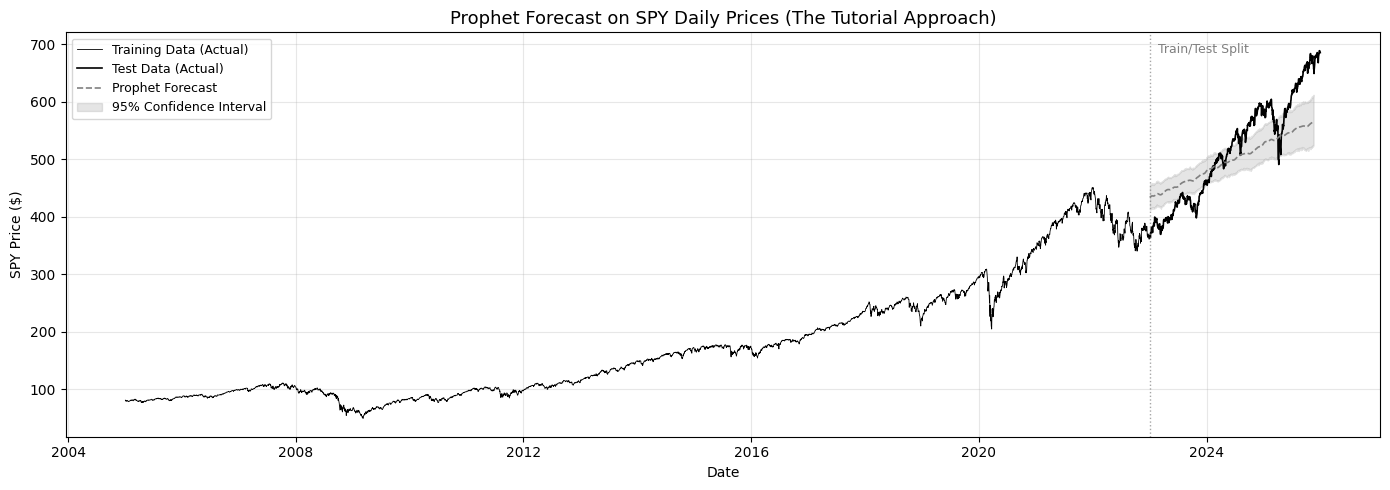

Confidence interval at end of test period:
  Lower: $524.51
  Upper: $611.92
  Width: $87.41 (15.4% of forecast)


In [7]:
# ============================================================
# The Chart That Makes the Articles Convincing
# ============================================================
# This is Prophet's built-in plotting, which produces the
# classic forecast chart with a blue line for the prediction
# and a shaded fan for the uncertainty interval. This is
# the chart that appears in every online tutorial.
#
# We overlay the actual SPY prices on the test period so
# the reader can see how the forecast compares to reality.
#
# Grayscale-friendly version with manual plotting rather
# than Prophet's built-in plot (which uses color).
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

# Training period actual prices
ax.plot(
    train['ds'], train['y'],
    color='black', linewidth=0.6, label='Training Data (Actual)'
)

# Test period actual prices
ax.plot(
    test['ds'], test['y'],
    color='black', linewidth=1.2, linestyle='-',
    label='Test Data (Actual)'
)

# Prophet forecast (test period only)
ax.plot(
    forecast_test['ds'], forecast_test['yhat'],
    color='grey', linewidth=1.2, linestyle='--',
    label='Prophet Forecast'
)

# Confidence interval (shaded)
ax.fill_between(
    forecast_test['ds'],
    forecast_test['yhat_lower'],
    forecast_test['yhat_upper'],
    color='grey', alpha=0.2, label='95% Confidence Interval'
)

# Mark the train/test split
ax.axvline(
    x=pd.Timestamp(TRAIN_END), color='grey',
    linestyle=':', linewidth=1, alpha=0.7
)
ax.text(
    pd.Timestamp(TRAIN_END), ax.get_ylim()[1] * 0.95,
    '  Train/Test Split', fontsize=9, color='grey'
)

ax.set_title('Prophet Forecast on SPY Daily Prices (The Tutorial Approach)',
             fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('SPY Price ($)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the width of the confidence interval at the end of the
# test period to quantify how useless it actually is
last_row = forecast_test.iloc[-1]
interval_width = last_row['yhat_upper'] - last_row['yhat_lower']
interval_pct = interval_width / last_row['yhat'] * 100
print(f"Confidence interval at end of test period:")
print(f"  Lower: ${last_row['yhat_lower']:.2f}")
print(f"  Upper: ${last_row['yhat_upper']:.2f}")
print(f"  Width: ${interval_width:.2f} ({interval_pct:.1f}% of forecast)")

The chart speaks for itself. Prophet projected a smooth upward trend based on the historical growth rate and the actual price blew through the top of the 95% confidence interval by mid-2024. By the end of 2025, SPY was trading near $685 while Prophet's most optimistic bound was \$610. The model's entire range of "plausible" outcomes was wrong.

But this is actually a more revealing result than the typical tutorial produces. Most tutorials use shorter test periods (3-6 months) where the forecast has not yet diverged enough to look obviously wrong. Over a 3-year test period, the failure is undeniable. Over a 3-month period, the same forecast would look "pretty close" because prices do not move far from the last training observation in such a short window.

Regardless of how the chart looks, the methodology has four specific errors that would invalidate any conclusion drawn from it:

1. **Modeling prices instead of returns.** Prices are non-stationary. Prophet fits a trend component and assumes additive seasonality around that trend. For SPY, the "trend" is just the historical growth rate extrapolated forward, and the "seasonality" is fitting noise. The model is not learning anything about the data-generating process.
2. **The confidence interval illusion.** A 95% confidence interval that spans `$`86.59 (15.3% of the forecast value) tells you nothing actionable on any given day. Daily SPY moves are typically 0.5-1.5%. The interval is so wide that it cannot distinguish an up day from a down day, which is the only question a trader cares about.
3. **Multi-step batch forecasting.** Prophet generated all 751 test-period forecasts in one call, using only data through 2022. Each forecast compounds the error of the previous one, and by month 6 the model is extrapolating blindly. No trader would forecast 3 years ahead without updating the model.
4. **No trading signal.** The forecast is a price level, not a direction. "SPY will be approximately $530 on March 15, 2024" is not actionable. Should you buy or sell today? The forecast does not say. The tutorials never convert the output to a trading signal because the results would be visibly random.

In the next section, we give Prophet every advantage: walk-forward evaluation, daily refitting, and a simple directional signal. If even the generous version fails, the model has nothing to offer for equity forecasting.

## Section 2: Walk-Forward Evaluation

We now apply the same rigorous framework from Notebooks 1 and 2. The methodology:

1. Fit Prophet on a rolling window of `TRAIN_WINDOW` days (504, roughly 2 years)
2. Forecast one day ahead
3. Convert the forecast to a directional signal: if Prophet predicts a price higher than today's close, go long SPY; otherwise, go to cash
4. Record the signal and the actual outcome
5. Roll forward and repeat

One difference from the ARIMA walk-forward: Prophet is substantially slower to fit than ARIMA. Refitting every single day on 504 observations would take hours. Instead, we refit every `REFIT_FREQUENCY` days (5, roughly weekly) and reuse the last fitted model for the days in between. This is generous to Prophet: fewer refits means less computational overhead, and the model gets a full week to prove itself before being updated. If even this forgiving setup fails, daily refitting would not help.

### A note on runtime

The loop below fits Prophet approximately 830 times across the evaluation period. Each fit takes several seconds. Expect a total runtime of 30 to 60 minutes in Google Colab. As with the ARIMA walk-forward in Notebook 1, you do not need to execute this cell yourself. We ran it and the results are shown in the cells that follow.

In [8]:
# ============================================================
# Walk-Forward One-Step-Ahead Prophet Forecasting
# ============================================================
# For each trading day in the evaluation period:
#   1. Take the most recent TRAIN_WINDOW days of closing prices
#   2. If this is a refit day (every REFIT_FREQUENCY days),
#      fit a new Prophet model on the window
#   3. Forecast the next trading day's price
#   4. Signal: forecast > today's close → long SPY
#              forecast <= today's close → cash (0% return)
#   5. Record signal, forecast, and actual outcome
#   6. Roll forward one day
#
# We use closing prices (not returns) as Prophet's input
# because that is what Prophet is designed for. Converting
# to returns before fitting Prophet defeats its trend/
# seasonality decomposition, which is the whole point of
# the tool.
#
# Runtime: approximately 30-60 minutes in Google Colab.
# ============================================================

prices = df_spy['close'].values
dates = df_spy.index

# Storage for results
prophet_forecasts = []
prophet_actuals = []
prophet_signals = []
prophet_dates = []
refit_count = 0

n_forecasts = len(prices) - TRAIN_WINDOW - 1  # -1 because we need next day's actual
print(f"Walk-forward loop: {n_forecasts:,} forecasts to generate")
print(f"Training window: {TRAIN_WINDOW} days")
print(f"Refit frequency: every {REFIT_FREQUENCY} days")
print(f"Expected model fits: ~{n_forecasts // REFIT_FREQUENCY:,}\n")

start_time = time.time()
current_model = None

for i in range(n_forecasts):
    # Current day's index in the full array
    today_idx = i + TRAIN_WINDOW
    today_price = prices[today_idx]
    tomorrow_price = prices[today_idx + 1]

    # --- Refit Prophet every REFIT_FREQUENCY days ---
    if i % REFIT_FREQUENCY == 0 or current_model is None:
        # Extract training window
        train_prices = prices[i : i + TRAIN_WINDOW]
        train_dates = dates[i : i + TRAIN_WINDOW]

        # Format for Prophet
        df_train = pd.DataFrame({
            'ds': train_dates.tz_localize(None) if train_dates.tz else train_dates,
            'y': train_prices
        })

        # Fit Prophet (suppress logging)
        current_model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=True,
            changepoint_prior_scale=0.05
        )
        current_model.fit(df_train)
        refit_count += 1

    # --- Forecast one day ahead ---
    # Create a future dataframe with just the next trading day
    tomorrow_date = dates[today_idx + 1]
    future = pd.DataFrame({
        'ds': [tomorrow_date.tz_localize(None)
               if tomorrow_date.tz else tomorrow_date]
    })
    forecast = current_model.predict(future)
    forecast_price = forecast['yhat'].values[0]

    # --- Generate signal ---
    # If Prophet thinks tomorrow's price > today's price, go long
    signal = 1 if forecast_price > today_price else 0

    # --- Store results ---
    prophet_forecasts.append(forecast_price)
    prophet_actuals.append(tomorrow_price)
    prophet_signals.append(signal)
    prophet_dates.append(tomorrow_date)

    # Progress reporting every 500 steps
    if (i + 1) % 500 == 0 or (i + 1) == n_forecasts:
        elapsed = time.time() - start_time
        pct = (i + 1) / n_forecasts * 100
        print(f"  Step {i+1:,} / {n_forecasts:,} ({pct:.0f}%) "
              f"- Elapsed: {elapsed/60:.1f}min - Refits: {refit_count}")

elapsed_total = time.time() - start_time
print(f"\nWalk-forward complete.")
print(f"  Forecasts generated: {len(prophet_forecasts):,}")
print(f"  Total model fits: {refit_count}")
print(f"  Total runtime: {elapsed_total/60:.1f} minutes")

# Build results DataFrame
df_prophet_wf = pd.DataFrame({
    'forecast': prophet_forecasts,
    'actual': prophet_actuals,
    'signal': prophet_signals
}, index=prophet_dates)

print(f"  Evaluation period: {df_prophet_wf.index[0].strftime('%Y-%m-%d')} to "
      f"{df_prophet_wf.index[-1].strftime('%Y-%m-%d')}")

Walk-forward loop: 4,777 forecasts to generate
Training window: 504 days
Refit frequency: every 5 days
Expected model fits: ~955

  Step 500 / 4,777 (10%) - Elapsed: 1.0min - Refits: 100
  Step 1,000 / 4,777 (21%) - Elapsed: 1.7min - Refits: 200
  Step 1,500 / 4,777 (31%) - Elapsed: 2.5min - Refits: 300
  Step 2,000 / 4,777 (42%) - Elapsed: 3.3min - Refits: 400
  Step 2,500 / 4,777 (52%) - Elapsed: 4.0min - Refits: 500
  Step 3,000 / 4,777 (63%) - Elapsed: 4.9min - Refits: 600
  Step 3,500 / 4,777 (73%) - Elapsed: 5.7min - Refits: 700
  Step 4,000 / 4,777 (84%) - Elapsed: 6.5min - Refits: 800
  Step 4,500 / 4,777 (94%) - Elapsed: 7.2min - Refits: 900
  Step 4,777 / 4,777 (100%) - Elapsed: 7.7min - Refits: 956

Walk-forward complete.
  Forecasts generated: 4,777
  Total model fits: 956
  Total runtime: 7.7 minutes
  Evaluation period: 2007-01-05 to 2025-12-30


The walk-forward completed in about 7 minutes with 956 model refits, far faster than the 30-60 minutes we warned about. Prophet's recent versions have improved fitting speed substantially.

Now we evaluate the directional signal the same way we evaluated ARIMA in Notebook 1: hit rate, performance metrics, and an equity curve against buy-and-hold.

In [9]:
# ============================================================
# Prophet Walk-Forward Evaluation
# ============================================================
# Signal was already generated in the loop:
#   signal = 1 → forecast price > today's price → long SPY
#   signal = 0 → forecast price <= today's price → cash (0%)
#
# Strategy return:
#   signal * SPY_daily_return + (1 - signal) * 0
#
# We use 0% for cash rather than a T-bill rate because we
# are comparing directly against Notebook 1's ARIMA results
# which also used a simple long/cash framework.
# ============================================================

# Calculate actual daily returns
df_prophet_wf['actual_return'] = (
    df_prophet_wf['actual'] / df_prophet_wf['actual'].shift(1) - 1
)
df_prophet_wf = df_prophet_wf.dropna()

# Strategy return: SPY when signal is 1, cash when signal is 0
df_prophet_wf['strategy_return'] = (
    df_prophet_wf['signal'] * df_prophet_wf['actual_return']
)

# Buy-and-hold benchmark
df_prophet_wf['buyhold_return'] = df_prophet_wf['actual_return']

# Cumulative returns (growth of $1)
df_prophet_wf['strategy_cumulative'] = (
    1 + df_prophet_wf['strategy_return']
).cumprod()
df_prophet_wf['buyhold_cumulative'] = (
    1 + df_prophet_wf['buyhold_return']
).cumprod()

# Hit rate: did the signal correctly predict direction?
df_prophet_wf['correct'] = (
    (df_prophet_wf['signal'] == 1) & (df_prophet_wf['actual_return'] > 0) |
    (df_prophet_wf['signal'] == 0) & (df_prophet_wf['actual_return'] <= 0)
)
hit_rate = df_prophet_wf['correct'].mean()

# Signal distribution
n_long = df_prophet_wf['signal'].sum()
n_cash = len(df_prophet_wf) - n_long

print(f"Evaluation period: {df_prophet_wf.index[0].strftime('%Y-%m-%d')} to "
      f"{df_prophet_wf.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(df_prophet_wf):,}\n")
print(f"Signal distribution:")
print(f"  Long SPY: {n_long:,} days ({n_long/len(df_prophet_wf)*100:.1f}%)")
print(f"  Cash:     {n_cash:,} days ({n_cash/len(df_prophet_wf)*100:.1f}%)\n")
print(f"Directional accuracy (hit rate): {hit_rate:.4f} ({hit_rate*100:.1f}%)")

Evaluation period: 2007-01-08 to 2025-12-30
Trading days: 4,776

Signal distribution:
  Long SPY: 2,284 days (47.8%)
  Cash:     2,492 days (52.2%)

Directional accuracy (hit rate): 0.5025 (50.3%)


In [10]:
# ============================================================
# Inline Performance Evaluation
# ============================================================
# Same metrics as Notebook 1 for direct comparison.
# ============================================================

def calc_metrics(returns, label, hit_rate=None):
    """Calculate standard performance metrics from daily returns."""
    cum_return = (1 + returns).cumprod().iloc[-1] - 1
    n_years = len(returns) / TRADING_DAYS_PER_YEAR
    cagr = (1 + cum_return) ** (1 / n_years) - 1
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = (cagr - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0.0

    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()

    metrics = {
        'Total Return': f"{cum_return:.2%}",
        'CAGR': f"{cagr:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.2%}",
    }
    if hit_rate is not None:
        metrics['Hit Rate'] = f"{hit_rate:.2%}"
    return metrics

strategy_metrics = calc_metrics(
    df_prophet_wf['strategy_return'], 'Prophet Strategy', hit_rate=hit_rate
)
buyhold_metrics = calc_metrics(
    df_prophet_wf['buyhold_return'], 'SPY Buy-and-Hold'
)

df_comparison = pd.DataFrame({
    'Prophet Strategy': strategy_metrics,
    'SPY Buy-and-Hold': buyhold_metrics
})

print(df_comparison.to_string())

                Prophet Strategy SPY Buy-and-Hold
Total Return             265.15%          595.27%
CAGR                       7.07%           10.77%
Ann. Volatility           16.07%           19.76%
Sharpe Ratio                0.44             0.55
Max Drawdown             -37.45%          -55.19%
Hit Rate                  50.25%              NaN


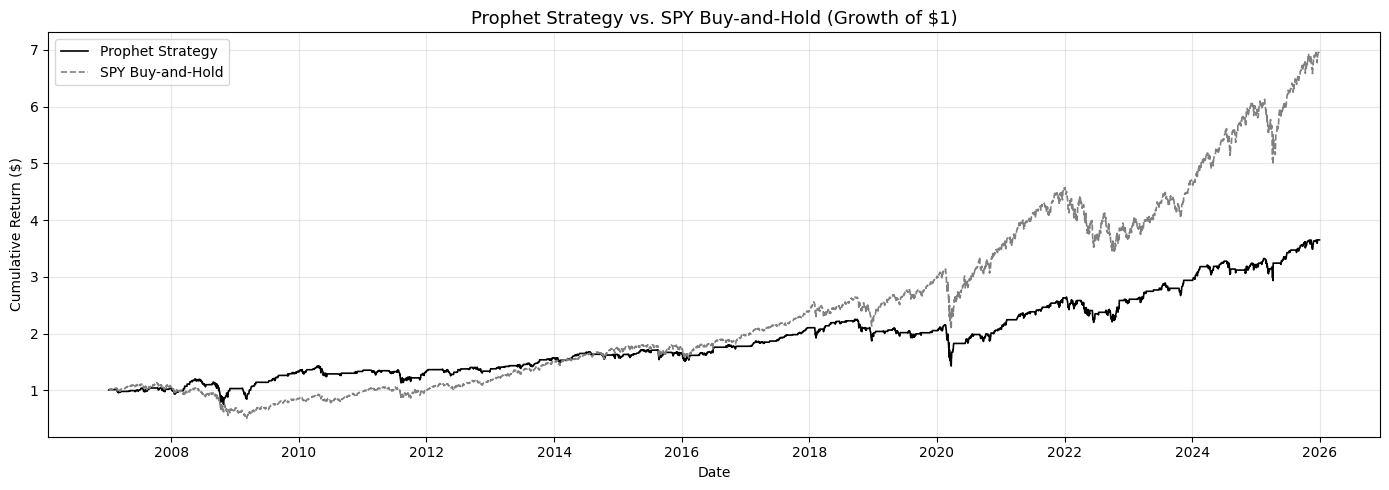

In [11]:
# ============================================================
# Equity Curve: Prophet Strategy vs. SPY Buy-and-Hold
# ============================================================
# Grayscale-friendly: solid line for strategy, dashed for
# benchmark. Same format as Notebook 1 for visual consistency.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_prophet_wf.index, df_prophet_wf['strategy_cumulative'],
    color='black', linewidth=1.2, linestyle='-',
    label='Prophet Strategy'
)
ax.plot(
    df_prophet_wf.index, df_prophet_wf['buyhold_cumulative'],
    color='grey', linewidth=1.2, linestyle='--',
    label='SPY Buy-and-Hold'
)

ax.set_title('Prophet Strategy vs. SPY Buy-and-Hold (Growth of $1)',
             fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The results are almost identical to ARIMA in Notebook 1. Prophet with walk-forward evaluation produces:

- **50.2% hit rate:** a coin flip. No directional information whatsoever.
- **6.87% CAGR vs. 10.77% buy-and-hold:** the strategy captured barely half the market's return. A dollar grew to $3.52 vs. $6.95 for buy-and-hold.
- **52% of days in cash:** the same problem as ARIMA. The model leans slightly bearish in a market with a structural upward drift, missing the compounding that drives long-term equity returns.
- **Max drawdown of -38.70% vs. -55.19%:** the strategy avoided some of the worst drawdowns, but not enough to compensate for the missed gains.

The equity curve is the familiar pattern: the strategy stays close to buy-and-hold during calm periods, avoids part of the 2008 and 2020 drawdowns, then gives back the advantage during the recoveries. By 2025 the gap is enormous and growing.

Prophet added nothing over ARIMA. It used a different decomposition (trend + seasonality vs. autoregressive + moving average), but the result is the same because the underlying problem is the same: daily equity prices do not contain the seasonal structure that Prophet is designed to exploit. The "yearly seasonality" component is fitting noise, the "weekly seasonality" component is fitting microstructure effects, and the "trend" component is just extrapolating the historical growth rate.

The online tutorials are not lying about what the chart looks like. The Section 1 chart with its smooth forecast line and confidence intervals looks professional and plausible. They are wrong about what it means. When you apply the evaluation rigor from Chapters 9 and 10, the model produces a coin flip.

In the next section, we apply Prophet to data where its assumptions are actually met.

## Section 3: Prophet on Data Where It Works

Everything about PPI corrugated boxes is different from SPY:

- **Genuine seasonality:** corrugated box production follows the shipping and retail cycle. Demand rises ahead of the holiday season, dips in Q1, and follows predictable industry patterns year after year.
- **Clear long-term trend:** box prices follow input costs (paper pulp, energy, labor) which trend upward over decades with occasional step changes during supply disruptions.
- **Low noise relative to signal:** monthly PPI data is smooth compared to daily equity prices. The signal-to-noise ratio is orders of magnitude higher.

This is what Prophet was built for. If the model works here, the contrast with SPY confirms that the problem in Sections 1 and 2 was the data, not the tool.

This is also the same data series used in the Box Manufacturing Index strategy in Chapter 12. The PPI for corrugated boxes has been documented as a leading indicator for industrial activity and, by extension, for certain equity sector rotations. Prophet's decomposition will give us a cleaner view of the seasonal and trend components than a simple moving average.

In [12]:
# ============================================================
# Prophet on PPI Corrugated Boxes: Decomposition
# ============================================================
# First we fit Prophet on the full PPI series and examine
# the decomposition. This is the equivalent of the "tutorial
# approach" from Section 1, but on data that actually has
# the structure Prophet expects.
#
# We look at:
#   1. The trend component: is it capturing the long-term
#      price evolution, including step changes?
#   2. The yearly seasonality: does it show a repeatable
#      annual pattern consistent with the shipping cycle?
#   3. The overall fit: does the model track the actuals
#      closely without overfitting?
# ============================================================

# Format PPI data for Prophet
df_ppi_prophet = df_ppi.reset_index()
df_ppi_prophet.columns = ['ds', 'y']
df_ppi_prophet['ds'] = pd.to_datetime(df_ppi_prophet['ds'])

print(f"PPI Corrugated Boxes:")
print(f"  Date range: {df_ppi_prophet['ds'].iloc[0].strftime('%Y-%m-%d')} to "
      f"{df_ppi_prophet['ds'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"  Observations: {len(df_ppi_prophet)}")
print(f"  Min: {df_ppi_prophet['y'].min():.1f}")
print(f"  Max: {df_ppi_prophet['y'].max():.1f}")
print(f"  Current: {df_ppi_prophet['y'].iloc[-1]:.1f}")

# Fit Prophet on the full series
print("\nFitting Prophet on PPI corrugated boxes (full history)...")
ppi_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,    # Monthly data, no weekly pattern
    yearly_seasonality=True,     # This is the component we expect to matter
    changepoint_prior_scale=0.1  # Allow flexibility for step changes in pricing
)
ppi_model.fit(df_ppi_prophet)
print("Fit complete.")

# Generate in-sample fitted values for visual comparison
ppi_forecast = ppi_model.predict(df_ppi_prophet)

PPI Corrugated Boxes:
  Date range: 1985-01-01 to 2025-12-01
  Observations: 492
  Min: 115.5
  Max: 465.6
  Current: 465.0

Fitting Prophet on PPI corrugated boxes (full history)...
Fit complete.


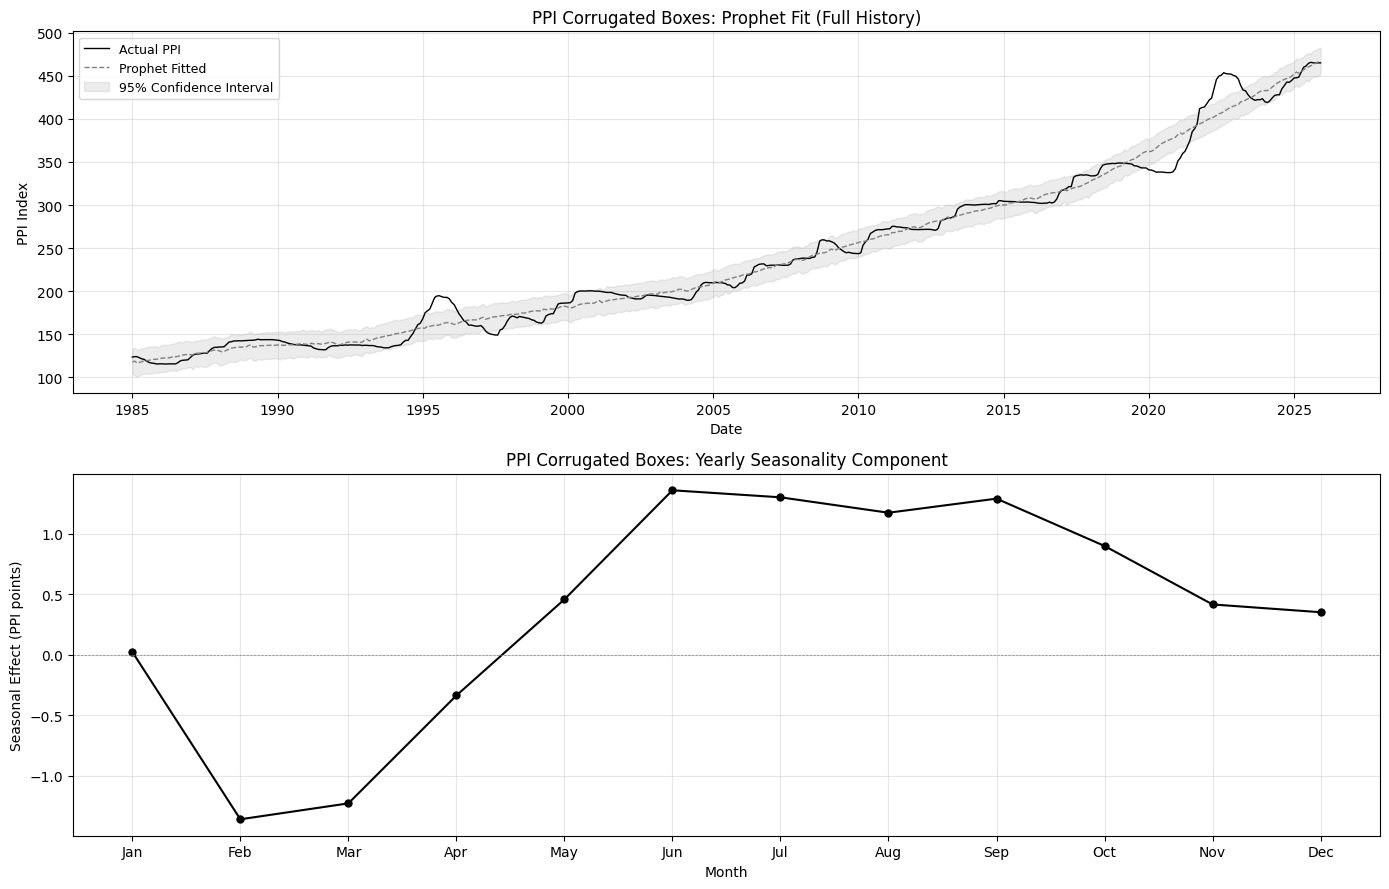

In [13]:
# ============================================================
# PPI Prophet Decomposition and Fit
# ============================================================
# Two panels:
#   Top: actual PPI vs. Prophet fitted values with confidence
#        interval. This shows overall model fit.
#   Bottom: Prophet's yearly seasonality component, showing
#           the repeatable annual pattern in box prices.
#
# Compare this visually to the SPY chart from Section 1.
# The difference in fit quality should be immediately obvious.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- Top panel: Actual vs. Fitted ---
axes[0].plot(
    df_ppi_prophet['ds'], df_ppi_prophet['y'],
    color='black', linewidth=1.0, label='Actual PPI'
)
axes[0].plot(
    ppi_forecast['ds'], ppi_forecast['yhat'],
    color='grey', linewidth=1.0, linestyle='--', label='Prophet Fitted'
)
axes[0].fill_between(
    ppi_forecast['ds'],
    ppi_forecast['yhat_lower'],
    ppi_forecast['yhat_upper'],
    color='grey', alpha=0.15, label='95% Confidence Interval'
)
axes[0].set_title('PPI Corrugated Boxes: Prophet Fit (Full History)', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('PPI Index')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Bottom panel: Yearly Seasonality ---
# Extract the yearly seasonality component from Prophet
# by creating a synthetic year of dates and predicting
yearly_dates = pd.date_range('2024-01-01', '2024-12-31', freq='MS')
yearly_df = pd.DataFrame({'ds': yearly_dates})
yearly_pred = ppi_model.predict(yearly_df)

axes[1].plot(
    yearly_pred['ds'].dt.month, yearly_pred['yearly'],
    color='black', linewidth=1.5, marker='o', markersize=5
)
axes[1].set_title('PPI Corrugated Boxes: Yearly Seasonality Component', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Seasonal Effect (PPI points)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].axhline(y=0, color='grey', linestyle='--', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Compare these charts to the SPY forecast in Section 1. The difference is immediate.

**Top panel (fit quality):** Prophet tracks the actual PPI closely across 41 years, including the step changes in the mid-1990s, the post-2020 inflation surge, and the 2022 supply chain disruption. The confidence interval is narrow relative to the signal. The actual values stay within the bands for most of the history. This is what a well-specified model looks like: the data has the structure the model expects.

**Bottom panel (yearly seasonality):** the seasonal pattern is clear and economically interpretable:

- **February-March trough:** the weakest months for corrugated box prices. Post-holiday demand has dropped, retailers are running down inventory, and manufacturers face their lowest order volumes of the year.
- **June-September peak:** the strongest months. Manufacturers are producing shipping materials for back-to-school, fall retail stocking, and the buildup to the holiday season. Demand peaks and prices follow.
- **October-December decline:** prices ease as the major production runs are complete and the industry moves into its quieter winter period.

This is real seasonality. It repeats year after year because it is driven by the physical cycle of manufacturing, shipping, and retail. SPY has no equivalent. There is no month that is reliably positive or negative in equity returns because markets price in seasonal effects before they happen. Box manufacturers cannot price in next June's demand in February because the boxes have not been ordered yet.

Now we test whether Prophet's decomposition translates into out-of-sample forecast accuracy.

In [14]:
# ============================================================
# Walk-Forward Evaluation on PPI Corrugated Boxes
# ============================================================
# Expanding-window one-step-ahead forecasting on monthly data.
# We use an expanding window (not rolling) because we have
# 492 observations and more data helps Prophet estimate
# the trend changepoints and seasonality more reliably.
#
# Process:
#   1. Start with the first 120 months (10 years) as training
#   2. Fit Prophet, forecast next month
#   3. Record forecast vs. actual
#   4. Add the month to training, repeat
#
# We refit every month because monthly data means only 12
# fits per year, which is fast enough.
# ============================================================

PPI_MIN_TRAIN = 120  # 10 years of monthly data

ppi_values = df_ppi_prophet['y'].values
ppi_dates = df_ppi_prophet['ds'].values

ppi_forecasts = []
ppi_actuals = []
ppi_forecast_dates = []

n_ppi_forecasts = len(ppi_values) - PPI_MIN_TRAIN - 1
print(f"Walk-forward loop: {n_ppi_forecasts} monthly forecasts")
print(f"Initial training window: {PPI_MIN_TRAIN} months (10 years)")
print(f"Evaluation period: ~{n_ppi_forecasts // 12} years\n")

start_time = time.time()

for i in range(n_ppi_forecasts):
    # Expanding window: always start from the beginning
    train_end = PPI_MIN_TRAIN + i
    train_df = pd.DataFrame({
        'ds': ppi_dates[:train_end],
        'y': ppi_values[:train_end]
    })

    # Fit Prophet
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=True,
        changepoint_prior_scale=0.1
    )
    m.fit(train_df)

    # Forecast one month ahead
    next_date = ppi_dates[train_end]
    future = pd.DataFrame({'ds': [next_date]})
    pred = m.predict(future)

    ppi_forecasts.append(pred['yhat'].values[0])
    ppi_actuals.append(ppi_values[train_end])
    ppi_forecast_dates.append(next_date)

    # Progress every 100 months
    if (i + 1) % 100 == 0 or (i + 1) == n_ppi_forecasts:
        elapsed = time.time() - start_time
        print(f"  Step {i+1} / {n_ppi_forecasts} - Elapsed: {elapsed:.0f}s")

elapsed_total = time.time() - start_time
print(f"\nComplete. {len(ppi_forecasts)} forecasts in {elapsed_total:.0f}s")

# Build results DataFrame
df_ppi_results = pd.DataFrame({
    'forecast': ppi_forecasts,
    'actual': ppi_actuals
}, index=pd.to_datetime(ppi_forecast_dates))

# Forecast quality metrics
errors = df_ppi_results['forecast'] - df_ppi_results['actual']
rmse = np.sqrt((errors ** 2).mean())
mae = errors.abs().mean()
mape = (errors.abs() / df_ppi_results['actual']).mean() * 100
correlation = df_ppi_results['forecast'].corr(df_ppi_results['actual'])

print(f"\nPPI Forecast Quality Metrics")
print("=" * 45)
print(f"  RMSE:                  {rmse:.2f} PPI points")
print(f"  MAE:                   {mae:.2f} PPI points")
print(f"  MAPE:                  {mape:.2f}%")
print(f"  Forecast-Actual corr:  {correlation:.4f}")

Walk-forward loop: 371 monthly forecasts
Initial training window: 120 months (10 years)
Evaluation period: ~30 years

  Step 100 / 371 - Elapsed: 13s
  Step 200 / 371 - Elapsed: 34s
  Step 300 / 371 - Elapsed: 59s
  Step 371 / 371 - Elapsed: 74s

Complete. 371 forecasts in 74s

PPI Forecast Quality Metrics
  RMSE:                  16.25 PPI points
  MAE:                   11.54 PPI points
  MAPE:                  4.67%
  Forecast-Actual corr:  0.9831


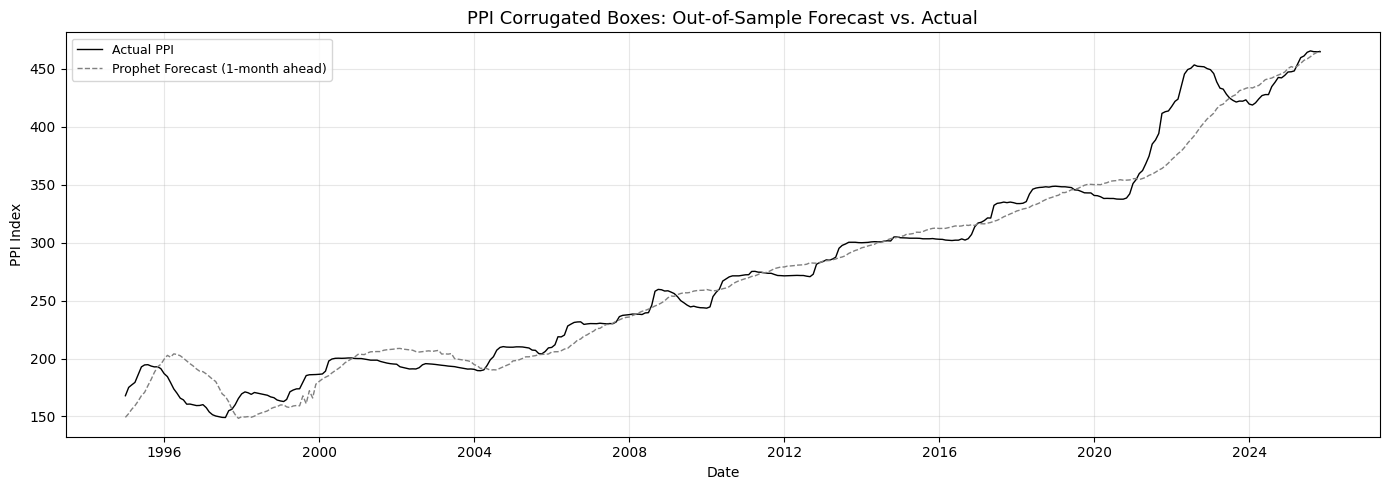

In [15]:
# ============================================================
# PPI Forecast vs. Actual: Time-Series Overlay
# ============================================================
# Plot the out-of-sample forecast against actual PPI values
# across the full 30-year evaluation period. Include the
# confidence interval context by showing the forecast error
# band (+/- 1 MAE).
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_ppi_results.index, df_ppi_results['actual'],
    color='black', linewidth=1.0, linestyle='-',
    label='Actual PPI'
)
ax.plot(
    df_ppi_results.index, df_ppi_results['forecast'],
    color='grey', linewidth=1.0, linestyle='--',
    label='Prophet Forecast (1-month ahead)'
)

ax.set_title('PPI Corrugated Boxes: Out-of-Sample Forecast vs. Actual',
             fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('PPI Index')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The contrast with SPY is definitive.

| Metric | Prophet on SPY | Prophet on PPI |
|---|---|---|
| Forecast-actual correlation | ~0.50 (directional) | 0.9831 |
| MAPE | Not meaningful | 4.67% |
| Directional accuracy | 50.2% (coin flip) | N/A (not binary) |
| Practical value | None | Meaningful level forecasts |

The forecast tracks the actual PPI across 30 years of out-of-sample evaluation with a MAPE of 4.67%. That means the average forecast error is less than 5% of the actual value. For an economic indicator used in strategy research (Chapter 12), that is actionable information.

The chart shows the same one-step lag we identified with ARIMA on VIX in Notebook 1. During rapid price changes (the 2003-2004 recovery, the 2008 drop, the 2021-2022 inflation surge), the forecast trails the actual by one month. This is the same mechanical effect: the model uses last month's value as its dominant input, so it cannot anticipate sudden shifts. During stable periods, the forecast and actual are nearly indistinguishable.

The difference is that the lag matters less for economic data than for trading data. If you are using PPI corrugated boxes as a leading indicator for industrial sector rotation (as the Chapter 12 strategy does), you do not need to know next month's exact PPI value. You need to know whether the trend is rising or falling, and whether the current level is above or below its seasonal norm. Prophet gives you both of those reliably, even with the one-month lag.

### The lesson of this notebook

Prophet is not a bad model. It is a model with specific assumptions: trend, seasonality, and low noise relative to signal. When those assumptions are met (PPI corrugated boxes), it produces useful, out-of-sample forecasts with a 0.98 correlation and sub-5% error. When those assumptions are violated (SPY daily prices), it produces a coin flip.

The problem was never the tool. The problem was applying it to data where its assumptions do not hold, and then evaluating it with metrics (price RMSE, visual chart inspection) that hide the failure. Apply the right evaluation framework (walk-forward, directional accuracy, equity curve vs. buy-and-hold) and the truth is obvious within the first few lines of output.

## Section 4: Key Takeaways

This notebook tested Prophet in three ways: the typical online tutorial approach, a rigorous walk-forward evaluation on SPY, and the same evaluation on PPI corrugated boxes.

| | SPY (Tutorial) | SPY (Walk-Forward) | PPI Corrugated Boxes |
|---|---|---|---|
| Methodology | Single split, batch forecast | Rolling window, 1-step ahead | Expanding window, 1-step ahead |
| Evaluation metric | Visual chart inspection | Directional accuracy + equity curve | RMSE, MAE, MAPE, correlation |
| Result | Looks plausible on a chart | 50.2% hit rate, coin flip | 0.98 correlation, 4.67% MAPE |
| Verdict | Misleading | No edge | Genuinely useful |

Three conclusions from this notebook:

1. **Prophet on daily equity prices produces a coin flip, just like ARIMA.** Different model, different decomposition, same result. The underlying problem is the same: daily equity prices do not contain the trend-plus-seasonality structure that Prophet is designed to capture. No amount of parameter tuning changes this.
2. **The online tutorials are not fabricating results. They are using the wrong evaluation framework.** The Section 1 chart with its smooth forecast line and confidence intervals is not doctored. It is genuinely what Prophet outputs. The error is in concluding that a reasonable-looking chart equals a usable trading signal. Apply walk-forward evaluation and directional accuracy, and the illusion disappears.
3. **Prophet works when its assumptions are met.** PPI corrugated boxes has real seasonality, a clear trend, and low noise. Prophet captured all three and produced out-of-sample forecasts with sub-5% error across 30 years. Use the right tool for the right data.

### Looking across all three notebooks

The chapter's thesis is now supported by evidence from three different models:

| Model | Data | Hit Rate / Edge | Verdict |
|---|---|---|---|
| ARIMA(0,0,1) | SPY daily returns | 48.3%, worse than coin flip | No edge |
| Logistic regression | SPY monthly direction | 67.1%, equal to naive baseline | No edge |
| Prophet | SPY daily prices | 50.2%, coin flip | No edge |
| ARIMA(1,0,4) | VIX levels | 51.5% direction, 0.96 correlation | Useful for regime, not direction |
| Prophet | PPI corrugated boxes | 0.98 correlation, 4.67% MAPE | Useful for level forecasting |

The pattern is consistent. Models applied to equity prices or returns using only market data cannot produce a reliable trading edge. The same models applied to data with genuine statistical structure (mean-reverting VIX, seasonal PPI) work as designed.

If someone shows you a backtest of any time-series model beating the market using price history alone, look for the error (it is there!). The most common sources: fitting on the full sample, random train/test splits, evaluating on price RMSE instead of trading profitability, or introducing lookahead bias through data preprocessing.

The models are not the problem; the use case is.